# Простые методы предсказания ВР

## Библиотека  SKTIME

### импорт

Библиотека [<b>Scikit-Time</b> (<b><code>Sktime</code></b> )](https://www.sktime.net/en/stable/) — это набор инструментов Python с [открытым исходным кодом](https://github.com/alan-turing-institute/sktime) для работы временными рядами. В основном библиотеки предполагает использование методов машинного обучения. 
Библиотеки расширяет `API scikit-learn` (а также некоторых [других библиотек](https://wandb.ai/site/articles/a-gentle-introduction-to-time-series-analysis-forecasting)) для задач временных рядов. Он предоставляет необходимые алгоритмы и инструменты преобразования для эффективного решения задач регрессии, прогнозирования и классификации. Библиотека включает специальные алгоритмы обучения временных рядов и методы преобразования. 
    
Отметим, что оригинальная статья по данным фреймворкам может быть найден [тут](https://arxiv.org/pdf/2005.08067.pdf). Также ряд фреймровко предлагают сравнение их функционала с конкурентами. Другими словами некторый обзор фрейморков. Такой обзор может быть найден, например, [тут](https://github.com/salesforce/Merlion?tab=readme-ov-file#comparison-with-related-libraries).

Если у вас не установленна данная библиотека, давайте установим ее при помощи следующего кода. Рекомендации по установке можно найти в официальной документации [тут](https://www.sktime.net/en/stable/installation.html). 

Отметим, что хоть мы и указываем тут код для установки компонент `sktime`, в общем случае рекомендуем установить полную версию пакета с использованием командной строки. Например, для этого можно использовать следующий скрипт
```bash
pip install --upgrade sktime[all_extras]
```

In [1]:
# !pip install --upgrade sktime[all_extras]

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter('once', FutureWarning)

In [3]:
import sktime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

In [4]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_evaluation import evaluate
from sktime.forecasting.compose import  TransformedTargetForecaster, AutoEnsembleForecaster
from sktime.forecasting.model_selection import temporal_train_test_split

from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.theta import ThetaForecaster
from sktime.forecasting.trend import PolynomialTrendForecaster, TrendForecaster, STLForecaster
from sktime.forecasting.fbprophet import Prophet
from sktime.forecasting.tbats import TBATS
from sktime.forecasting.bats  import BATS
from sktime.forecasting.ets   import AutoETS

from sktime.forecasting.statsforecast import (StatsForecastAutoETS, 
                                              StatsForecastAutoTheta,
                                              StatsForecastAutoCES,
                                              StatsForecastMSTL)

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier

from sktime.utils.plotting import plot_series
from sktime.transformations.series.detrend import Deseasonalizer, Detrender

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="skbase")

In [5]:
# настройка стиля по ГОСТ
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'figure.figsize': (10, 6),
    # 'axes.spines.top': False,
    # 'axes.spines.right': False
})

### Чтение данных

В качестве набора данных давайте загрузим рассмотренный ранее набор данных о потреблении электричества в Германии. 

In [6]:
df = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)



,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


### Создание univariate dataset

В первую очередь в данном уроке мы будем рассматривать однопеременные методы (`univariate time series`). Поэтому выберем один из столбцов данных в качестве отдельного временного ряда. 

Кроме того, в ходе предыдущего анализа было установлено, что ряд имеет как минимум 3 составляющие (быструю, с периодом сутки, среднюю с периодом неделя и медленную с периодом 1 год). Для упрощения анализа и без значительных потерь значимости удалим быструю составляющую при помощи перегруппировки данных.

In [7]:
y = df.Consumption.asfreq('W')
#y.index = y.index.to_period("W")
SEASON = 53 # 53 недели в году
y.head()

time
2015-01-04    38.517
2015-01-11    41.048
2015-01-18    42.468
2015-01-25    43.563
2015-02-01    42.863
Freq: W-SUN, Name: Consumption, dtype: float64

#### Визуализация

Проведем визуализацию полученных данных при помощи встроенных утилит.

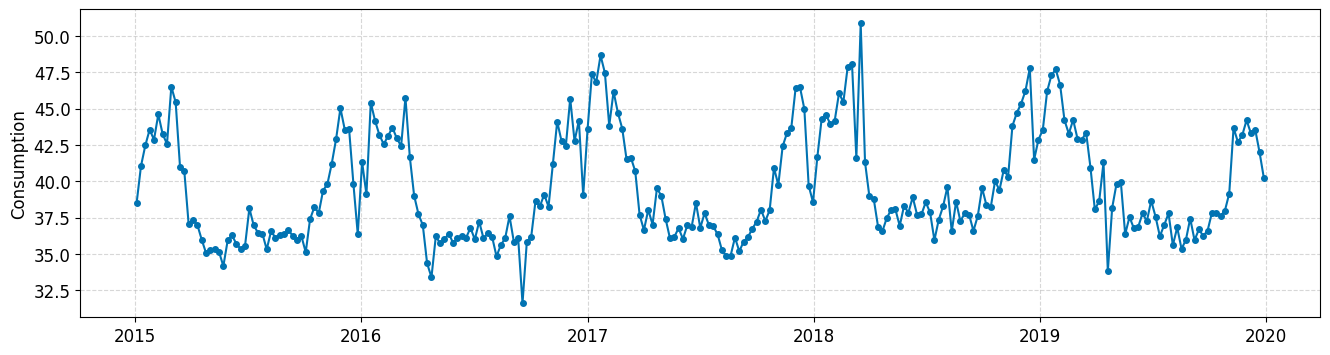

In [8]:
plot_series(y);

Немного улучшим стить

In [9]:
def fix_plot(y, ax=None, tick_step=20, date_format='%Y-%m-%d'):
    if ax is None:
        ax = plt.gca()
    
    # Берём каждую tick_step-ю дату из индекса
    tick_dates = y.index[::tick_step]
    tick_labels = tick_dates.strftime(date_format)
    
    # Устанавливаем тики именно по датам (не по позициям!)
    ax.set_xticks(tick_dates)          # ← ключевое отличие!
    ax.set_xticklabels(tick_labels)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

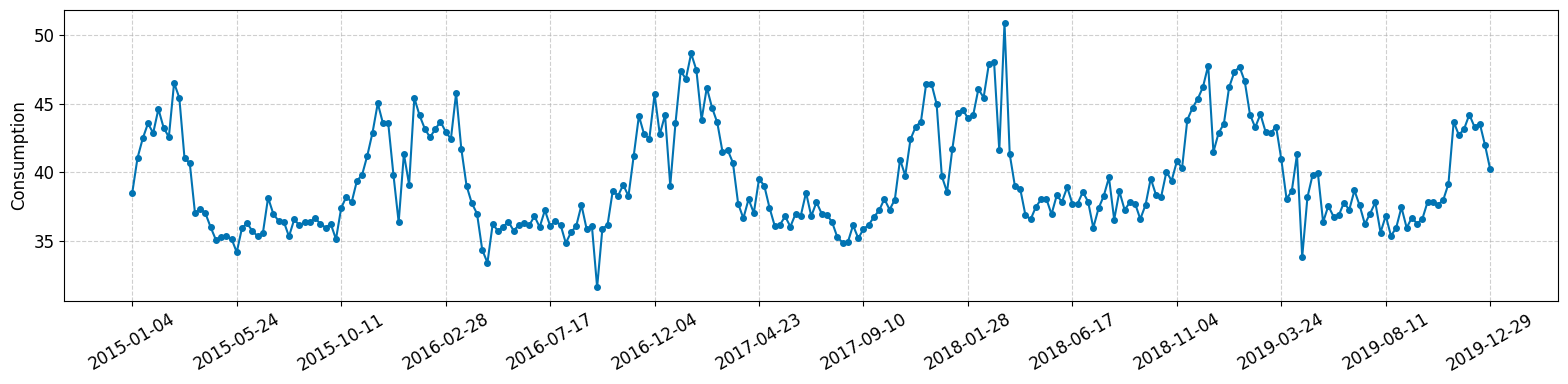

In [10]:
plot_series(y)
fix_plot(y)

#### temporal_train_test_split

Для разделения данных воспользуемся функцией `temporal_train_test_split`, которая позволяет адаптировать разделение данных не разрушая временные зависимости в данных. Отметим, что данная функция не единственный тип разделения данных. Более подробную информацию можно найти [тут](https://notebooks.githubusercontent.com/view/ipynb?browser=chrome&color_mode=auto&commit=24f6be86f95bfc1ec246dee7dcdd455e0a84a872&device=unknown&enc_url=68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f616c616e2d747572696e672d696e737469747574652f736b74696d652f323466366265383666393562666331656332343664656537646364643435356530613834613837322f6578616d706c65732f77696e646f775f73706c6974746572732e6970796e62&logged_in=false&nwo=alan-turing-institute%2Fsktime&path=examples%2Fwindow_splitters.ipynb&platform=android&repository_id=156401841&repository_type=Repository&version=98).

Check splitted data size: Train: 173, Test: 88


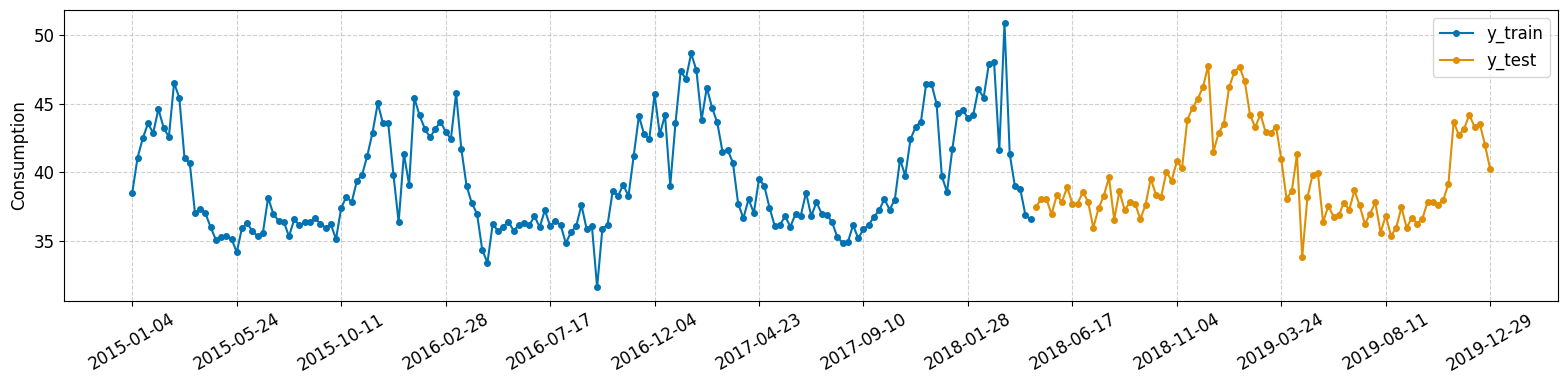

In [11]:
from sktime.split import temporal_train_test_split

TEST_SIZE = int(0.34 * y.size)

y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

print(f'Check splitted data size: Train: {y_train.shape[0]}, Test: {y_test.shape[0]}')

plot_series(y_train, y_test, labels=["y_train", "y_test"])
fix_plot(y)

## Наивные методы предсказания

### Методы предсказания

В целом задача предсказания значений ВР представляет собой [обширный перечень методов](https://neerc.ifmo.ru/wiki/index.php?title=Анализ_временных_рядов). Методы могут быть разделены на различные таксономии. В том числе по тому, какие задачи могут быть решены, или [наприммер](https://www.sas.com/content/dam/SAS/en_ca/User%20Group%20Presentations/Edmonton-User-Group/NateDerby-TimeSeriesForecastingNovember2009.pdf), по уровню соответствующего статистического подхода.

<img src="https://i.pinimg.com/736x/4b/79/b7/4b79b73b6b7bef191a9e582d387a39f0.jpg" width="900px">

<!-- или например

<img src="https://www.researchgate.net/publication/358080275/figure/fig2/AS:1120768494698499@1644223440381/Classification-of-time-series-forecasting-methods-and-models.png" width="900px"> -->

В этом занятии мы рассмотрим только самые простые подходы к решению задачи предсказания. В том числе:
* [наивные методы](https://otexts.com/fpp3/simple-methods.html) предсказания - когда следущие значения в каком виде повторояют одно из предыдущих.
* методы на основе [скользящего/экспоненциального сглаживания](https://otexts.com/fpp3/expsmooth.html) - когда следующие значения являются результатам некоторой фильтрации набора предыдущих значений (обработки ВР окном или окнами с весовыми параметрами).
* методы на основе [регрессии](https://otexts.com/fpp3/regression.html) - в которых предлагается некоторя модель детерминированного ВР на фоне шумов и некоторое решение для оценки параметров этой модели. Модели могут быть как линейные, так и [нелинейные](https://otexts.com/fpp3/advanced.html).

In [12]:
from sktime.registry import all_estimators

all_estimators(
    "forecaster", 
)

[('ARCH', sktime.forecasting.arch._uarch.ARCH),
 ('ARDL', sktime.forecasting.ardl.ARDL),
 ('ARIMA', sktime.forecasting.arima._pmdarima.ARIMA),
 ('AutoARIMA', sktime.forecasting.arima._pmdarima.AutoARIMA),
 ('AutoETS', sktime.forecasting.ets.AutoETS),
 ('AutoEnsembleForecaster',
  sktime.forecasting.compose._ensemble.AutoEnsembleForecaster),
 ('AutoREG', sktime.forecasting.auto_reg.AutoREG),
 ('AutoTS', sktime.forecasting.autots.AutoTS),
 ('BATS', sktime.forecasting.bats.BATS),
 ('BaggingForecaster', sktime.forecasting.compose._bagging.BaggingForecaster),
 ('BoxCoxBiasAdjustedForecaster',
  sktime.forecasting.boxcox_bias_adjusted_forecaster.BoxCoxBiasAdjustedForecaster),
 ('CINNForecaster',
  sktime.forecasting.conditional_invertible_neural_network.CINNForecaster),
 ('ChronosForecaster', sktime.forecasting.chronos.ChronosForecaster),
 ('ColumnEnsembleForecaster',
  sktime.forecasting.compose._column_ensemble.ColumnEnsembleForecaster),
 ('ConformalIntervals', sktime.forecasting.conformal

### Выбор горизонта предсказания

Помимо разделения данных на тренированные и тестовые предсказание в `sktime` может потребовать т.н. `forecasting horizon` - то есть непосредственного указания числа предсказываемых значений. Такой горизонт предсказания можно задавать по разному, при помощи массива или объекта класса `ForecastingHorizon`. Последний способ предоставляет более развитый инструментарий.

In [13]:
#fh = np.arange(y_test.size) + 1
fh = ForecastingHorizon(y_test.index, is_relative=False)

### Выбор метрик предсказния

Для начала давайте попробуем выполнить наивное предсказание. То есть каждое следующее предсказанное значение будет лишь копией предыдущего, начиная с последнего значение тренировочной выборки.

Для оценка качества прогнозов будем использовать метрики [проверки ошибок предсказания](https://otexts.com/fpp3/accuracy.html). 

В качестве базовой метрики воспользуемся [симметричной средней процентной ошибкой](https://mlpills.dev/time-series/error-metrics-for-time-series-forecasting/) (<b>symmetry Mean Average Percentage Error, [sMAPE](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.performance_metrics.forecasting.MeanAbsolutePercentageError.html)</b>) 


$$ sMAPE =2\frac{1}{H}\sum_{i=1}^{H} \frac{|y(h_i) − \hat{y}(h_i)|}{|y(h_i)| + |\hat{y}(h_i)|}
 $$
    
    
Также будем использовать `RMSE` — среднеквадратичная ошибка, подчёркивает большие выбросы

Давайте ввдем еще две метрики, показывающая на сколько модель лучше baseline:

обощенная метрика скилл
```skill = 1 - mae(y_pred_complex, y_test)/mae(y_pred_naive, y_test)```

MASE -  качество модели по сравнению с наивной моделью независимо от масштаба ряда
```MASE = 1 - mae(y_pred_complex, y_test)/mae(y_pred_naive, y_test)```

Метрика показывает «насколько модель лучше простого наивного прогноза»

Отметим, что на самом деле [в sktime](https://github.com/sktime/python_brasil_2025/blob/main/notebooks/part1/04_metricas.ipynb) можно найти и другие интересные метрики

In [14]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanSquaredError, MeanAbsoluteScaledError, MeanAbsoluteError
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="skbase")
def print_metrics(y_true, y_pred_complex, y_pred_naive, y_train = None):
    smape = MeanAbsolutePercentageError(symmetric=True)
    mse   = MeanSquaredError()
    mae = MeanAbsoluteError() 

    if not y_train: y_train = y_true
    s_c = mae(y_pred_complex, y_true)
    s_n = mae(y_pred_naive, y_true)
    mae_naive_insample = np.mean(np.abs(y_train[1:] - y_train[:-1]))
    mase = s_c / (mae_naive_insample + 1e-8)
    skill = 1 - s_c / (s_n+1e-8)

    print(f"sMAPE: {smape(y_pred_complex, y_true):.3f}")
    print(f"RMSE:  {np.sqrt(mse(y_pred_complex, y_true)):.3f}")
    print(f"MASE:  {mase:.3f}")
    print(f"Skill: {skill:.3f}")

### Простое наивное предсказание

В рамках данного занятия мы рассмотрим наиболее [простые алгоритмы предсказания](https://forecasting-encyclopedia.com/theory.html#introduction_to_the_theory_of_forecasting), которые условно разделим на:
* **Наивные методы предсказания** [(`NaiveForecasters`)](https://otexts.com/fpp3/simple-methods.html), позволяющие оценивть будущие значения как некоторые простые преобразования имеющихся значений ВР.
* **Подход на основе моделей экспоненциального сглаживания** [Exponential smoothing](https://otexts.com/fpp3/taxonomy.html) и [модфикаций подхода](https://openforecast.org/adam/exponential-smoothing.html).
* **Методы с использованием** [регрессионных подходов](https://otexts.com/fpp3/regression.html) как простых, так и [современных](https://otexts.com/fpp3/prophet.html).

__Наивные методы__ (например, прогноз «последнее значение») нужны как базовая точка отсчёта.
Они показывают минимальный уровень ошибки, с которым должна справляться любая более сложная модель. Если сложная модель хуже наивной — значит, что-то не так с данными или подходом.

sMAPE: 0.083
RMSE:  4.526
MASE:  330002272.727
Skill: 0.000


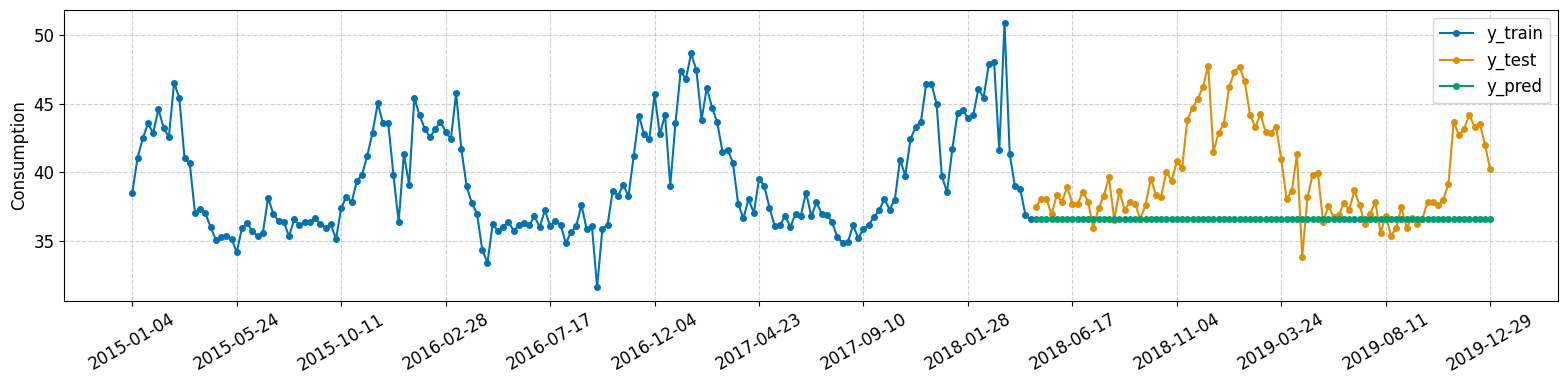

In [15]:
# ПРЕДСКАЗАТЕЛЬ
forecaster = NaiveForecaster(strategy="last")
forecaster.fit(y_train)

# ПРЕДСКАЗАНИЕ
y_pred = forecaster.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]);
fix_plot(y);

# ОШИБКА
print_metrics(y_test, y_pred, y_pred)

для будущих Skill

In [16]:
y_pred_naive = y_pred.copy()

#### сезонное наивное предсказание

Также давайте попробуем оценить точность наивного сезонного предсказания. В данном случае указана статегия `strategy="mean"` это означает что значения будут выбраны как средние. Это могут быть средние значения по всей тренировочной выборке или по заданному окну размера `window_length`. В данном случае окно не указано, поэтому в качестве его длины выбрана вся длина ВР.

C:\Users\Ronkin\AppData\Roaming\Python\Python39\site-packages\skbase\base\_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


sMAPE: 0.047
RMSE:  2.286
MASE:  184915530.303
Skill: 0.440


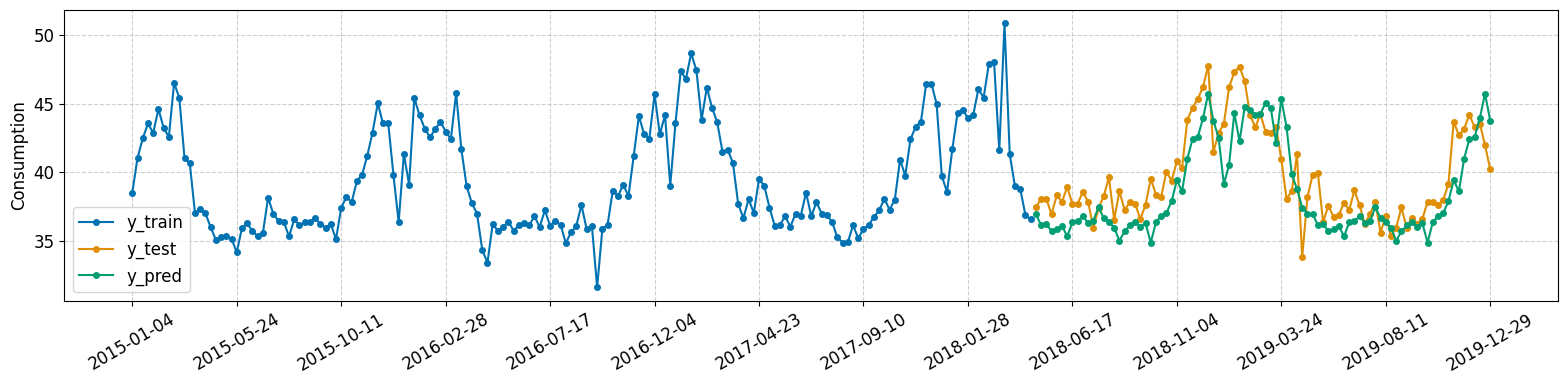

In [17]:
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster.fit(y_train)

y_pred = forecaster.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]); fix_plot(y);

print_metrics(y_test, y_pred, y_pred_naive)

Отметим, что список всех доступных методов оценки может быть найден в следующем виде

In [18]:
# all_estimators("forecaster", as_dataframe=True)

## Методы экспоненциального сглаживания

### Simple Exponential Smoothing (SES)

Одними из наиболее простых методов являются семейство методов на основе экспоненциального сглаживания   (`Exponential Smoothing`, `Holt-Winter` и другие). Давайте посмотрим на их работу. Для начала оценим точность наиболее простого варианта `Simple Exponential Smoothing`.

SES  учитывает только прошлые значения с затухающими весами.
Чем ближе к настоящему, тем больше вес.
Используется, чтобы сгладить шум и получить простую модель уровня ряда, которая тоже служит базой для сравнения с более сложными методами.

Напомним, что простое экспоненциальное сглажевание выполняет тот же расчет взвешенного скользящего среднего (метод pandas <tt>.ewm()</tt>):<br>
$\begin{align}y_0 &= x_0 \\
y_t &= (1 - \alpha) y_{t-1} + \alpha x_t,\end{align}$

Чем α ближе к 1, тем прогноз быстрее реагирует на новые данные (меньше сглаживания)
Чем α ближе к 0, тем прогноз более «плавный», ориентирован на долгосрочный уровень ряда

коэффициент может быть выбран и автоматически

sMAPE: 0.079
RMSE:  4.381
MASE:  314467345.490
Skill: 0.047


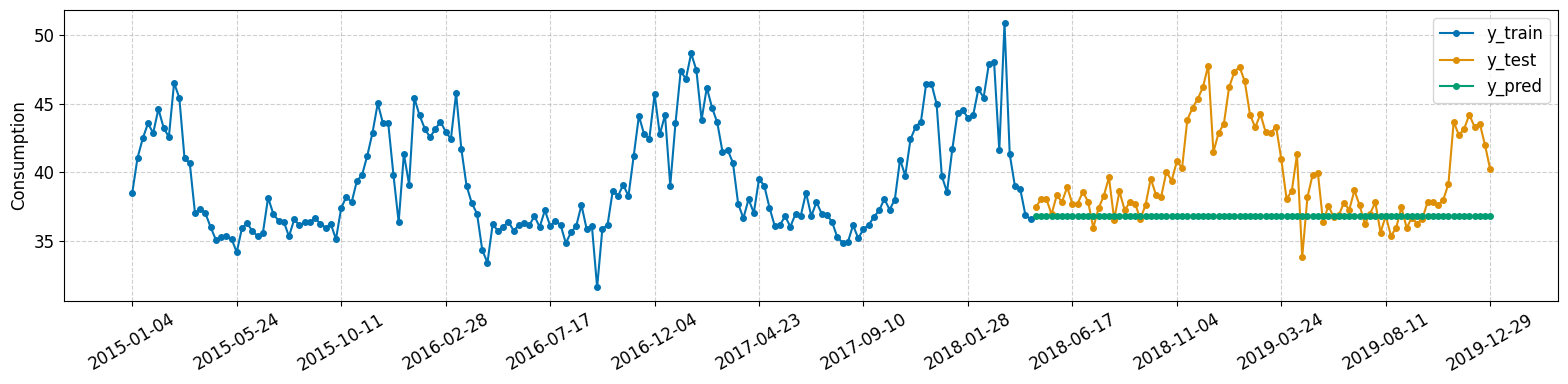

In [19]:
forecaster = ExponentialSmoothing()
forecaster.fit(y_train)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]); fix_plot(y);

print_metrics(y_test, y_pred, y_pred_naive)

### In and Out of sample задачи

На самом деле можно выделить 2 задачи предсказания:

- __In-sample-prediction__   - задача когда предполагается, что данные постоянно пополняются и мы получаем новый прогноз на основе реальных наблюдений
- __Out-of-sample-forecasting__  - задача предсказания новых и неизвестных данных, по сути все будущие предсказания опираются на последние имеющиеся данные. Как правило тут чем дальше от последнего наблюдения, тем меньше точность.

В нашем случае мы можем промоделировать 
- In-sample-prediction при помощи y_train  - можно использовать чтобы сравнить, насколько алгоритм повторяет данные.
-  Out-of-sample-forecasting при помощи y_test - прогнозы на тестовом периоде.

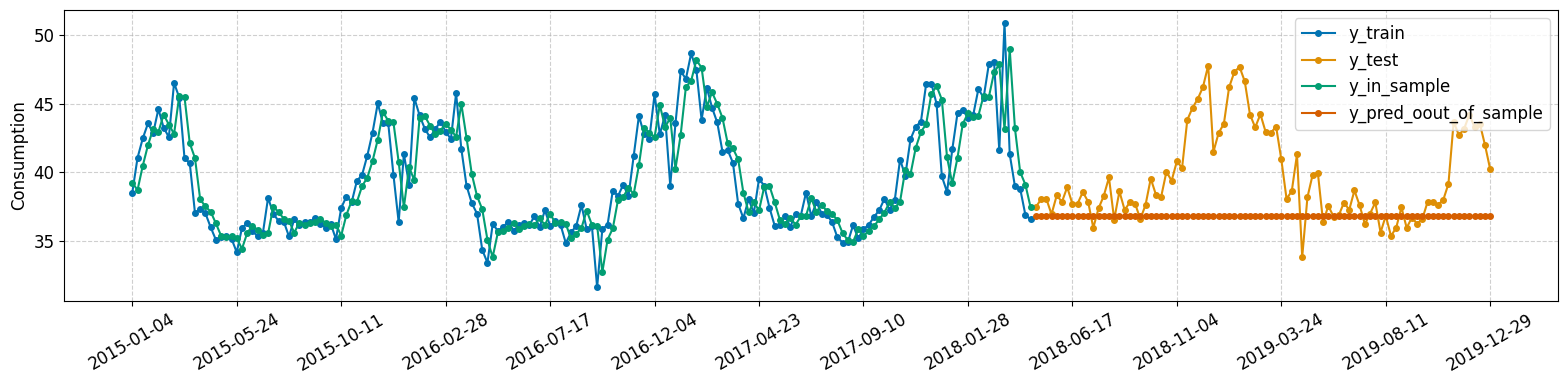

In [20]:
forecaster = ExponentialSmoothing()
forecaster.fit(y_train)
y_pred = forecaster.predict(fh)

# Построим оба прогноза: in-sample и out-of-sample
y_insample = forecaster.predict(fh=y_train.index)  # для in-sample

plot_series(y_train, y_test, y_insample, y_pred, labels=["y_train", "y_test", "y_in_sample", "y_pred_oout_of_sample"])
fix_plot(y)

#### выбор коэффициента сглаживания

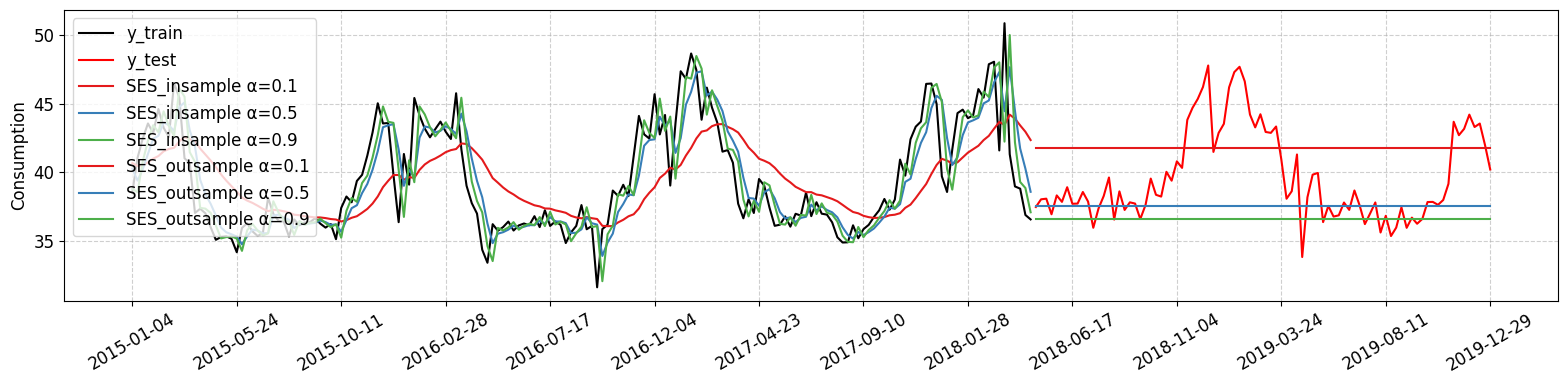

In [21]:
alphas = [0.1, 0.5, 0.9]

# прогнозы
forecasts = []
forecasts_insample = []

for alpha in alphas:
    forecaster = ExponentialSmoothing(smoothing_level=alpha)
    forecaster.fit(y_train)
    forecasts.append(forecaster.predict(fh))
    forecasts_insample.append(forecaster.predict(fh=y_train.index))

# цвета
colors = plt.cm.Set1(range(len(alphas)))  # или plt.cm.tab10, или любая другая палитра

# серия и метки
all_series = [y_train, y_test] + forecasts_insample + forecasts
all_labels = ["y_train", "y_test"] + [f"SES_insample α={x}" for x in alphas] + [f"SES_outsample α={x}" for x in alphas]

# цвета: для insample и outsample — одинаковые
color_list = ['black', 'red']  # для y_train, y_test
for c in colors:
    color_list.append(c)  # insample
for c in colors:
    color_list.append(c)  # outsample

plot_series(*all_series, labels=all_labels, markers=["" for _ in range(len(all_series))], colors=color_list)
fix_plot(y)

### Theta - метод

Theta-метода является расширением  метода экспоненциального сглаживания (SES). Theta-метод получил своё название от того, что использует две "тета"-линии, полученные из исходного ряда метода экспоненциального сглаживания. таким образом Theta-метод разлагает временной ряд на долгосрочный тренд и локальную (SES) компоненту, позволяя моделировать и краткосрочные колебания. Метод особенно эффективен на данных с явно выраженным трендом, но без сильной сезонности. 

В sktime Theta-метод представлен классом ThetaForecaster и StatsForecastAutoTheta которые позволяют:

- Автоматически определять наличие тренда и его тип (линейный, квадратичный, затуахющий),
- Учитывать сезонность (если она указана),
- Прогнозировать как на основе  тренда, так и на основе адаптивной SES-компоненты.
- StatsForecastAutoTheta: авто-выбор нескольких вариантов модели: (Standard, Optimized, Dynamic,)

Модель включает следующие шаги:
1. Устранение сезонности (`Deseasonalize`) если та определена. 
2. Построение двух линейных моделей прогноза - модель линейной регресии и модель простого скользящего среднего.
3. Объеденение двух моделей. Отметим, что в оригинальной идеи моделей может быть и больше двух.
4. Восстоновление сезонной составляющей.

<!-- В последних версиях пакета `sktime` также предлагается и альтернативная реализация метода [`StatsForecastAutoTheta`](https://nixtla.github.io/statsforecast/models.html#autotheta) эта версия реализована в новом и очень перспективном пакете [`statsforecast`](https://github.com/Nixtla/statsforecast) от компании [nixtla](https://www.nixtla.io/). [Особенностью данной реализации](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autotheta.html) является поиск среди нескольких вариантов моделей данного семейства, в том числе:  <tt>Standard Theta Model (`STM`), Optimized Theta Model (`OTM`), Dynamic Standard Theta Model (`DSTM`), Dynamic Optimized Theta Model (`DOTM`) </tt>. При необходимости тип модели может быть задан параметром `model`.

>Данная компания в том числе предлагает модель TimeGPT. Орагнизация подобного рода доступа к подобным рессурсам является главной особенностью фреймворка sktime. -->

sMAPE: 0.043
RMSE:  2.185
MASE:  171958639.223
Skill: 0.479


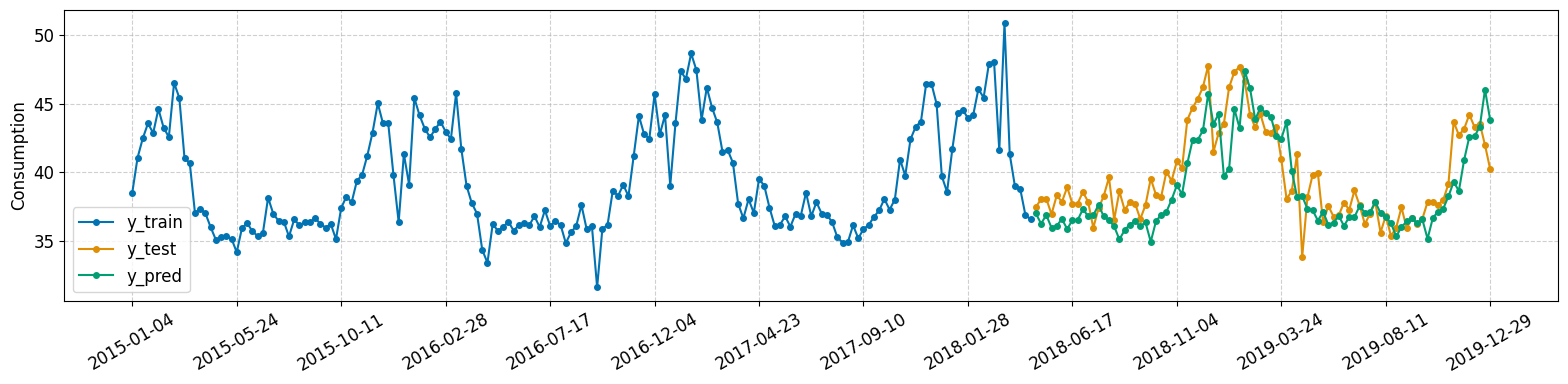

In [22]:

from sktime.forecasting.statsforecast import StatsForecastAutoTheta

# Создаём модель
theta_auto = StatsForecastAutoTheta(season_length=SEASON, decomposition_type='multiplicative')

# Обучаем
theta_auto.fit(y_train)

# Прогнозируем
y_pred = theta_auto.predict(fh)

# Визуализируем
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

# Метрики
print_metrics(y_test, y_pred, y_pred_naive)

#### Комплексная экспоненциальная модель CES

Другим примером [экспоненциальных моделей](https://openforecast.org/adam/exponential-smoothing.html) является комплексная экспоненциальная модель [CES](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoces.html). Этот подход позволяет рассмотреть модель как сумму линейного трнеда и сложного комплексного тренда (цикличности), которая бы включала в себя и сезонную составляющу. Для модели такого рода строится экспонециальное сглаживание. Модель реализуется также в пакете `Nixtla`. В [sktime](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.statsforecast.StatsForecastAutoCES.html) это `StatsForecastAutoCES`.


sMAPE: 0.049
RMSE:  2.374
MASE:  199275362.360
Skill: 0.396


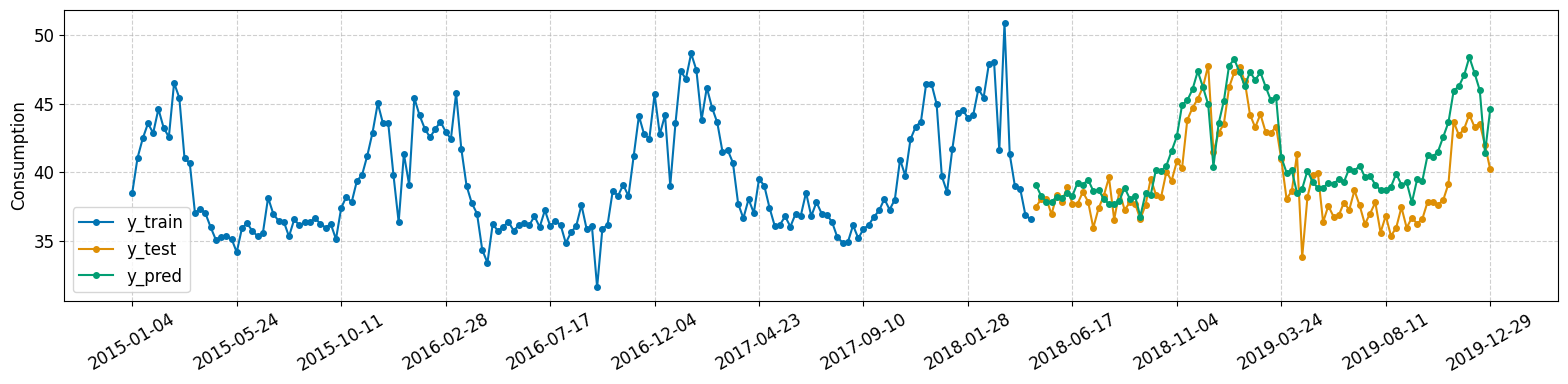

In [23]:
forecaster =  StatsForecastAutoCES(season_length = 52)

forecaster.fit(y_train, fh=fh)
y_pred = forecaster.predict(fh)

y_pred = y_pred.reindex(y_test.index)

# Визуализация
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

print_metrics(y_test, y_pred, y_pred_naive)

### Другие методы скользящего среднего

#### Holt


Holt:
sMAPE: 0.093
RMSE:  4.858
MASE:  363800632.283
Skill: -0.102

Damped Holt:
sMAPE: 0.082
RMSE:  4.472
MASE:  323727958.631
Skill: 0.019


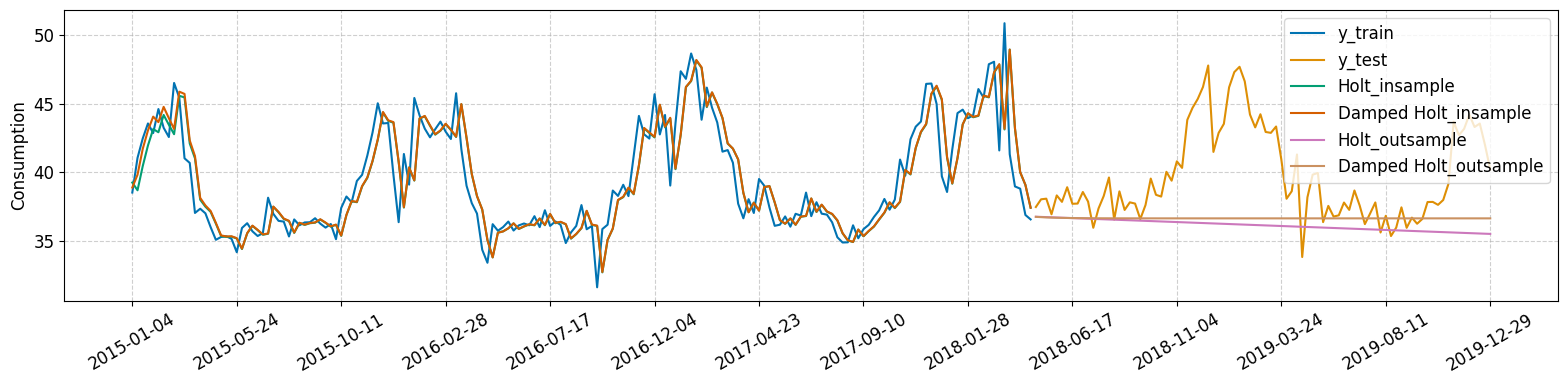

In [24]:
methods = {
    "Holt": ExponentialSmoothing(trend="add", damped_trend=False, sp=SEASON),
    "Damped Holt": ExponentialSmoothing(trend="add", damped_trend=True, sp=SEASON),
}

# обучение и прогноз
predictions = {}
predictions_insample = {}

for name, forecaster in methods.items():
    forecaster.fit(y_train)
    predictions[name] = forecaster.predict(fh)
    predictions_insample[name] = forecaster.predict(fh=y_train.index)

# график
all_series = [y_train, y_test] + list(predictions_insample.values()) + list(predictions.values())
all_labels = ["y_train", "y_test"] + [f"{name}_insample" for name in methods.keys()] + [f"{name}_outsample" for name in methods.keys()]

plot_series(*all_series, labels=all_labels, markers=["" for _ in range(len(all_series))])
fix_plot(y)

# метрики
for name, pred in predictions.items():
    print(f"\n{name}:")
    print_metrics(y_test, pred, y_pred_naive)

#### Holt-Winter


Holt-Winter:
sMAPE: 0.049
RMSE:  2.435
MASE:  195983460.423
Skill: 0.406

Holt-Winter Mul:
sMAPE: 0.053
RMSE:  2.526
MASE:  207937458.653
Skill: 0.370

Holt-Winter dump:
sMAPE: 0.052
RMSE:  2.432
MASE:  205927804.075
Skill: 0.376


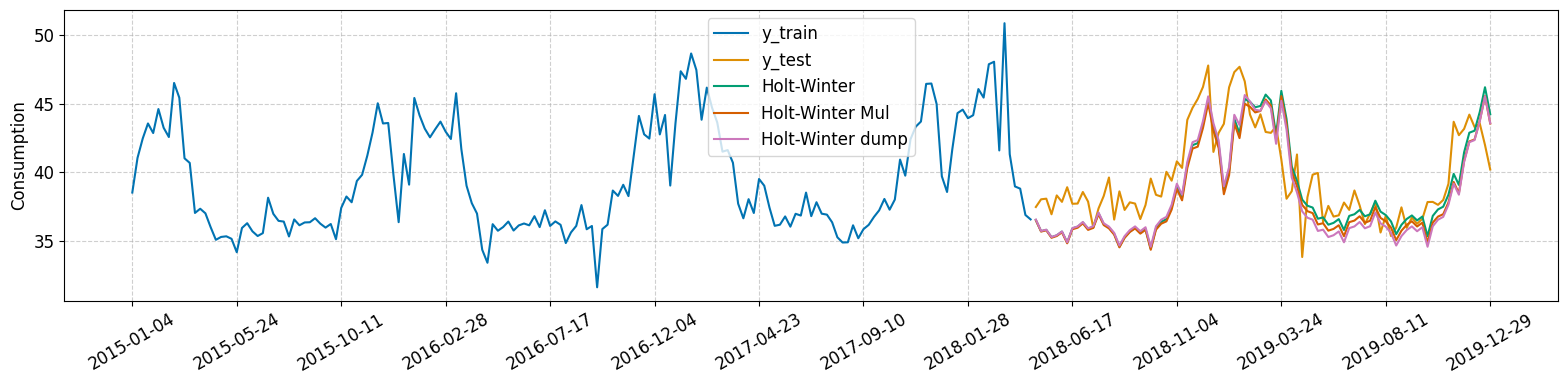

In [25]:
methods = {
    "Holt-Winter": ExponentialSmoothing(trend="add", seasonal="additive", sp=SEASON, initialization_method='estimated'),
    "Holt-Winter Mul": ExponentialSmoothing(trend="mul", seasonal="additive", sp=SEASON,initialization_method='estimated'),
    "Holt-Winter dump": ExponentialSmoothing(trend="add", seasonal="additive", damped_trend=True,  sp=SEASON,initialization_method='estimated'),
}

# обучение и прогноз
predictions = {}
for name, forecaster in methods.items():
    forecaster.fit(y_train)
    predictions[name] = forecaster.predict(fh)

# график
all_series = [y_train, y_test] + list(predictions.values())
all_labels = ["y_train", "y_test"] + list(predictions.keys())

plot_series(*all_series, labels=all_labels, markers=["" for _ in range(len(all_series))])
fix_plot(y)

# метрики
for name, pred in predictions.items():
    print(f"\n{name}:")
    print_metrics(y_test, pred, y_pred_naive)

#### Ансамбль методов скользящего среднего

Точность в предыдущих случаях оставляла желать лучшего. Однако, теперь давайте посмотрим на возможность ансамблирования таких методов

sMAPE: 0.052
RMSE:  2.432
MASE:  204742201.331
Skill: 0.380


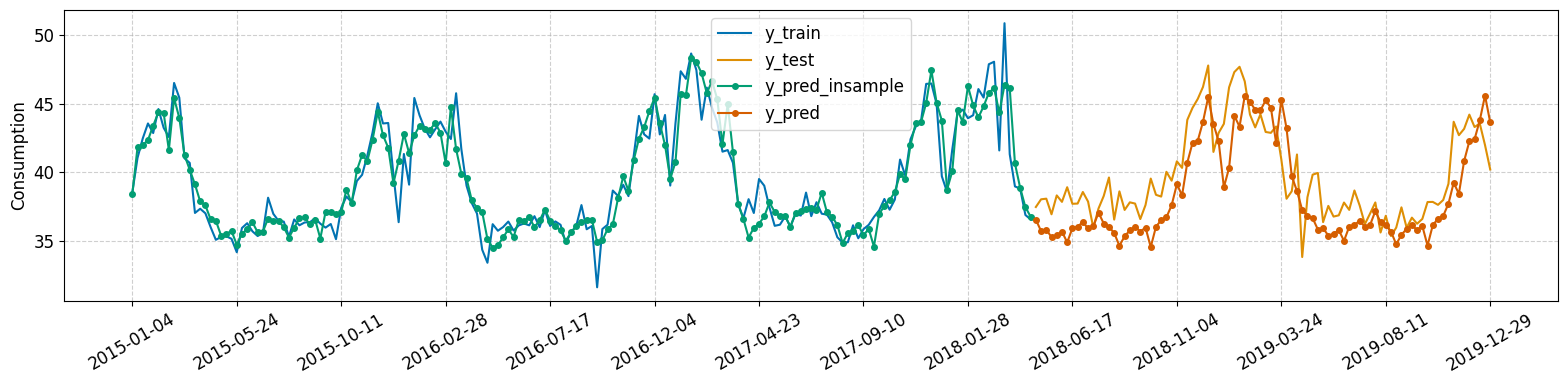

In [26]:
# обучение и прогноз
forecaster = AutoEnsembleForecaster(list(methods.items()))
forecaster.fit(y_train)

y_pred = forecaster.predict(fh)
y_pred_insample = forecaster.predict(fh=y_train.index)

# график
plot_series(y_train, y_test, y_pred_insample, y_pred, 
            labels=["y_train", "y_test", "y_pred_insample", "y_pred"],
            markers=["", "", "o", "o"]
           )
fix_plot(y)

print_metrics(y_test, y_pred, y_pred_naive)

## AutoETS (Auto-Error-Trend-Season)

В общем случае пакет `sktime` позволяет использовать автоматизированный подбор параметров модели экспоненциального сглаживания. Для этого может быть использован пакет `AutoETS`. Модель, реализуемая данным пакетом также называется `Error-Trend-Season (ETS)`. В случае необходимости исследователь может вручную задать параметры модели, в формате `ETS(X,X,X)s`</b>, где `X` может быть <tt>N-None, A-additive, M-multiplicative, Ad-additive dumped</tt>, `s`-период сезона или `None`. 

Частными примерами модели `ETS` являются:
* Simple Exponential smoothing `ETS(A,N,N)`.  
* Triple Exponential smoothing `ETS(A,A,A)`. 
* и многие другие.

Модели AutoETS  сами выбирает оптимальную комбинацию компонентов и параметры, включая необходимость дополнительнго преобразования тренда (бокс-кокс). Однако данные модели требуют обозначения сезонности.  Использование таких моделей удобно для коротких или сложных рядов, где трудно заранее понять тренд. 

> Отметим, что <tt>Exponential smoothing</tt> использует эвристические значения для начальных состояний, а затем оценивает параметры сглаживания, оптимизируя функцию потерь `MSE`. В тоже время `ETS()` оценивает и начальные состояния, и параметры сглаживания, оптимизируя функцию максимального правдоподобия (`NNL`) (что эквивалентно оптимизации MSE только для линейных аддитивных моделей). \
> В ряде случаев можно также рассматривать и другие модели на основе экспоненциального сглаживания, например [с регрессией](https://orbit-ml.readthedocs.io/en/stable/tutorials/dlt.html) или с разделением [глобального и т.н. локального тренда](https://num.pyro.ai/en/stable/tutorials/time_series_forecasting.html).

sMAPE: 0.064
RMSE:  2.896
MASE:  249411776.901
Skill: 0.244


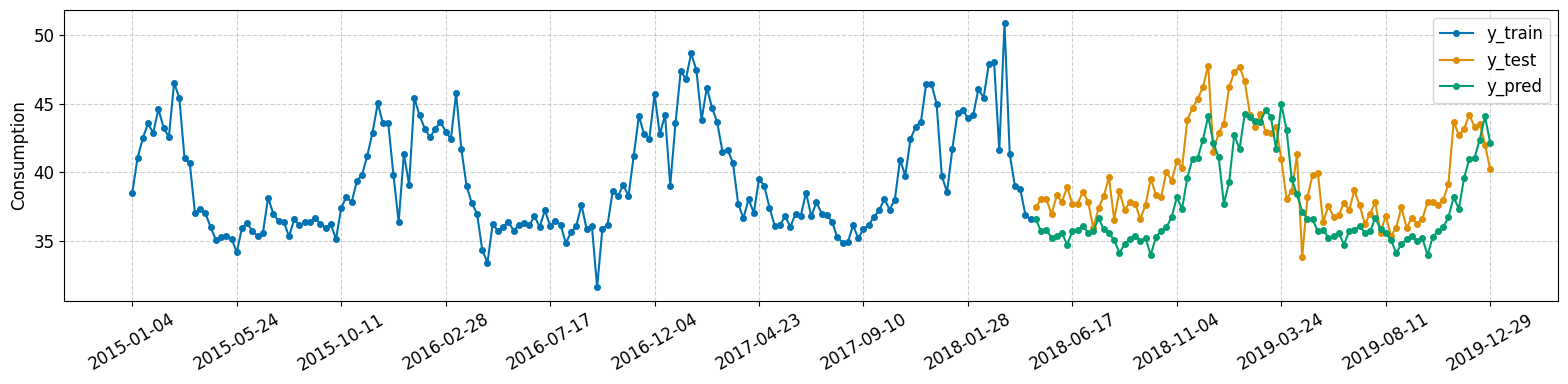

In [27]:
forecaster = AutoETS(auto=True, sp=SEASON, n_jobs=-1)

forecaster.fit(y_train)

y_pred = forecaster.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]); fix_plot(y);

print_metrics(y_test, y_pred, y_pred_naive)

### StatsForecastAutoETS

Отметим, что аналогично может быть использован подход [`StatsForecastAutoETS`](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoets.html). Особенностью данного подхода является автовыбор не только коэффициентов моделей, но и их конфигураций. Для этого искомые конфигурации помечаются индексом `Z`.

sMAPE: 0.039
RMSE:  2.086
MASE:  158329058.392
Skill: 0.520


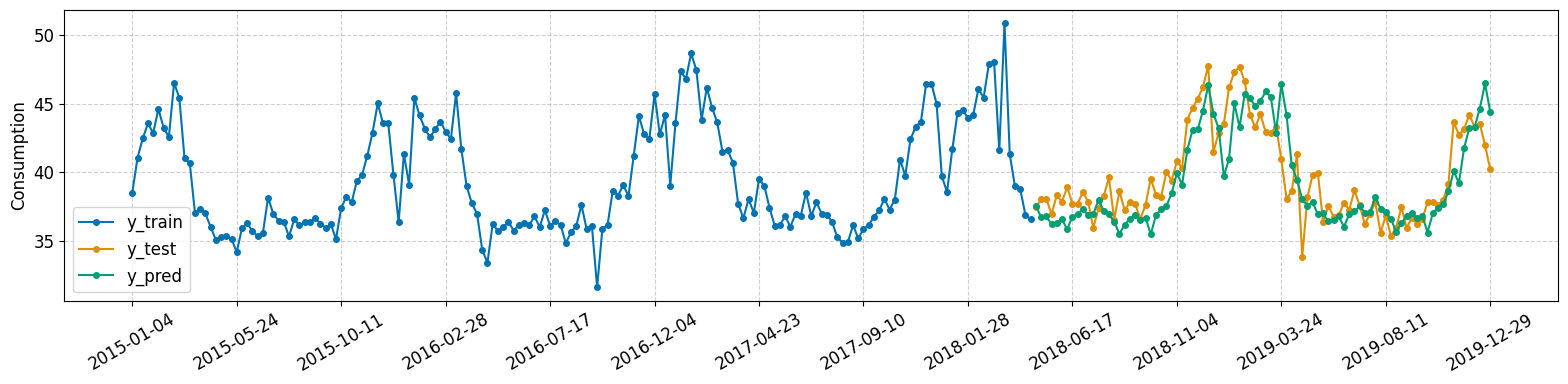

In [28]:
forecaster = StatsForecastAutoETS(season_length = SEASON,
                              model = 'ZZM',
                                  damped = True,)

forecaster.fit(y_train, fh=fh)
y_pred = forecaster.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y);

print_metrics(y_test, y_pred, y_pred_naive)


In [29]:
!pip install -U statsforecast>=1.3.2

## Разложение ВР и простые методы прогноза

### STL from statsmodels

Одним из методов оценки данных с вилянием сезонности и тренда является использование предварительной декомпозиции  временного ряда. Одним из наиболее простых методов декомпозиции является разделение на тренд, сезонность и остаток.  Давайте посмотрим на то, как будут выглядеть результаты такого разложения.


>* Отметим, что в наиболее простом случае разложить ВР $y(t)$ на составляющие можно бы было следующим алгоритмом 
>* Вычислить тренда $T(t)$, например методом скользящего среднего с длинным окном.
>* Вычислить функционала вида  $y(t)-T(t)$ (`Detrend`).
>* Вычислить основную сезонную составляющую $S(t)$ путем усреднение знечений с шагом сезонности `s`. Например, для месячных данных сезонный компонент для марта представляет собой среднее значение всех мартовских значений в данных без тренда. Этот шаг можно бы было проделать для каждого значения сезонности.  
>* Создать ряд сезонностей $S(t)$ заданной длительности.
>* Вычислить остаток разложения $R(t) =y(t)-T(t)-S(t)$
>
>Однако, такое разложение было бы не стабильным к нестационарностям,  редким событиям (в т.ч. аномалиям и регулярным событиям) и сложному виду тренда.
<!-- https://medium.com/analytics-vidhya/time-series-forecasting-using-tbats-model-ce8c429442a9
https://otexts.com/fpp2/classical-decomposition.html
https://www.openforecast.org/adam/classical-seasonal-decomposition.html
http://www.gardner.fyi/blog/STL-Part-II/ -->

В общем случае пакет [`sktime`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.trend.STLForecaster.html) включает ряд методов, использующих разлжение ВР в целях предсказания. Одним из наиболее популярных среди таковых является использование `STL` (<tt>Seasonal-Trend decomposition using LOESS </tt>) предсказания. Метод позволяет разложить ВР устойчиво к типичным выбросам и редким событиям. 
Метод заключается в использовании двух циклов:
* внутренний цикл:
    * вычисляется приблизительный тренд, например как линейная аппроксимация данных.
    * вычисляются сезонные составляющие путем усреднения с заданынм сезоном.
    * Далее вычисляется оконечный вид тренд из данных без сезонной части. Вычисление производится путем локальной взвешенной регрессии <tt>LOESS</tt>.
    * вычисляется остаток разолжения.
* внешний цикл минимизирует влияние выбросов в остатке разложения. 

Метод может быть напрямую использован для предсказаний. Метод реализован в `sktime` в двух вариантах, один из которых относится к классической библиотеке [statsmodels](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html), а второй к новой и перспективной библиотеке [nixtla](https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html). Мы используем только второй вариант.  Отметим, что в данном варианте также заложена возможность для аппроксимации нескольких сезонных компонент.

Также отметим, что после аппроксимации разложения предсказатель для тренда [может быть заменен на альтернативными методами](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html).


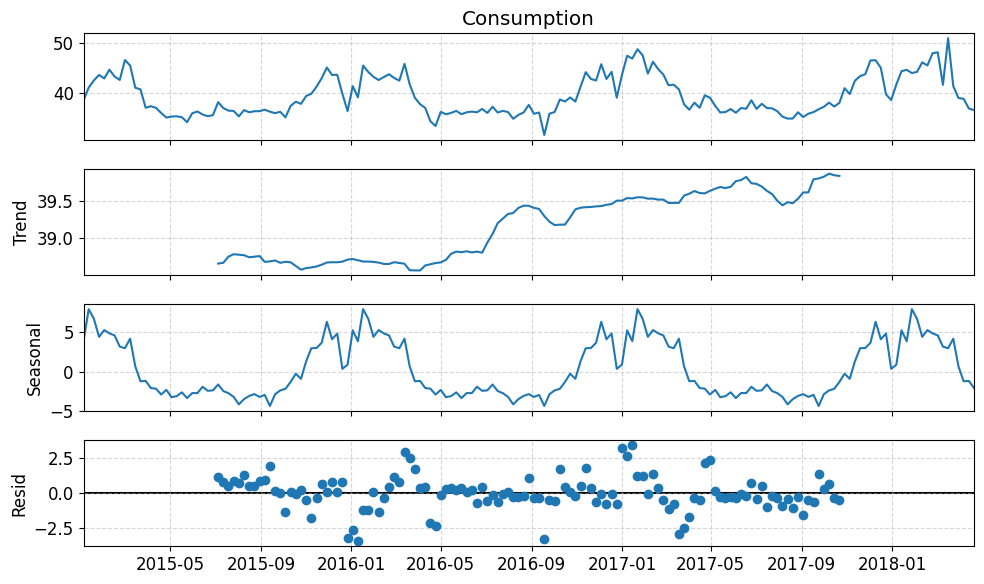

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y_train, model='additive', period = SEASON)
result.plot();

### Deseasonalizer/Detrender

В рамках пакета `SKTime` наиболее простое разложение можно выполнить при помощи объектов класса `Deseasonalizer` и `Detrender`. Давай для начала посмотрим отдельно на их работу

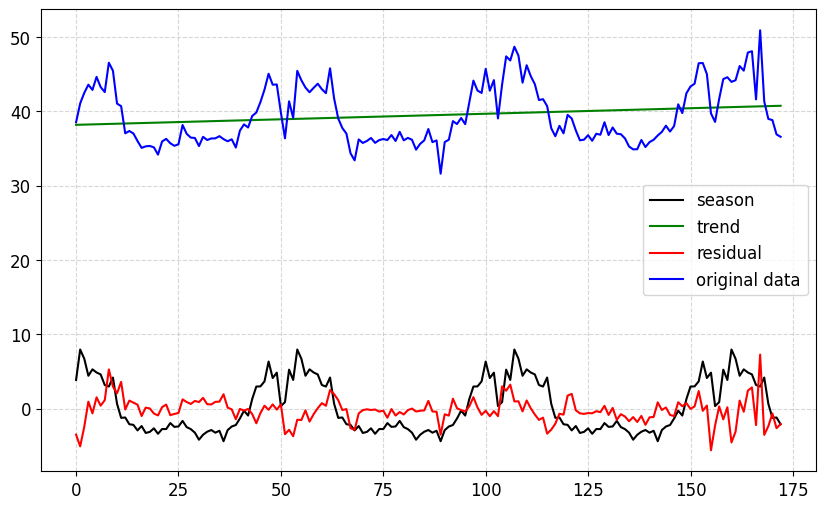

In [31]:
deseason = Deseasonalizer(model="additive", sp=SEASON) #Remove seasonal components from a time series.
detrend  = Detrender(forecaster=TrendForecaster())

season   = y_train.values.squeeze() - deseason.fit_transform(y_train.values).squeeze()
trend    = y_train.values.squeeze() - detrend.fit_transform(y_train.values).squeeze()
residual = y_train.values.squeeze() - trend - season

plt.plot(season, c='k', label='season')
plt.plot(trend, c='g', label='trend')
plt.plot(residual, c='r', label='residual')
plt.plot(y_train.values, c='b', label='original data')
plt.legend()
plt.show()

Для каждой из указанных частей  (трнед и сезонность) можно бы было построить по отдельному прогнозу, которые затем бы были просуммированы (аддитивная модель). Более того сезонных составляющих может быть несколько.
На практике для такого разложения проще использовать контейнер `TransformedTargetForecaster` - который является некоторым аналогом пайплайна.

### Предсказание с использованием разложения тренд-сезон-остаток

Разложение указанного типа это сложная операция. Для каждой из  частей ВР  (трнед и сезонность) можно бы было построить по отдельному прогнозу, которые затем бы были просуммированы (аддитивная модель). Более того сезонных составляющих может быть несколько.
На практике для такого разложения проще использовать контейнер `TransformedTargetForecaster` - который является некоторым аналогом пайплайна.

В нашем случае проведем следующее разложение:
* Удалим аддитивную сезонность. Позже она будет просто экстраполироваться наивным методом.
* Проведем аппроксимацию тренда при помощи полиномимальной регрессии. Позже регрессия будет давать прогноз значений.
* Остаток будем прогнозировать скользящим средним.

Такой пайплайн дает максимальную интерпретацию результатов и является достаточно простым, что снижает риски переобучения. 

sMAPE: 0.043
RMSE:  2.186
MASE:  173013566.644
Skill: 0.476


C:\Users\Ronkin\AppData\Roaming\Python\Python39\site-packages\sktime\performance_metrics\forecasting\_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


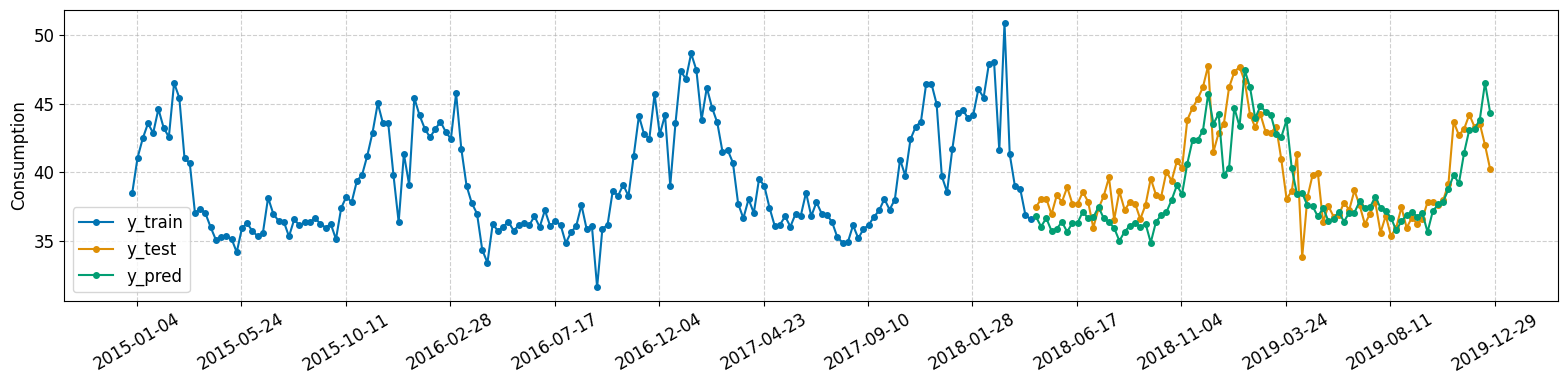

In [32]:
y_train_ = y_train.copy().asfreq('W').to_period('W')
y_test_  = y_test.copy().asfreq('W').to_period('W')

# Горизонт предсказания
fh = ForecastingHorizon(y_test_.index, is_relative=False)

# Пайплайн SES через deseasonalize + polynomial detrend
forecaster = TransformedTargetForecaster(
    steps=[
        ("deseasonalize", Deseasonalizer(model="additive", sp=SEASON)),  
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=2))),
        ("forecaster", ExponentialSmoothing(trend=None, seasonal=None))  # SES
    ])

# Обучение
forecaster.fit(y_train_)

# Предсказание
y_pred = forecaster.predict(fh)

# Приведение индекса
y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train_, y_test_, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

print_metrics(y_test_, y_pred, y_pred_naive)

#### Multiple Seasonal-Trend decomposition (MSTL)

В SKTime также может быть использован метод Multiple Seasonal-Trend decomposition из библиотеки StatsForecast, который позволяет автоматически раскладывать ряд на несколько сезонных составляющих.

sMAPE: 0.049
RMSE:  2.351
MASE:  193352986.538
Skill: 0.414


C:\Users\Ronkin\AppData\Roaming\Python\Python39\site-packages\sktime\performance_metrics\forecasting\_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


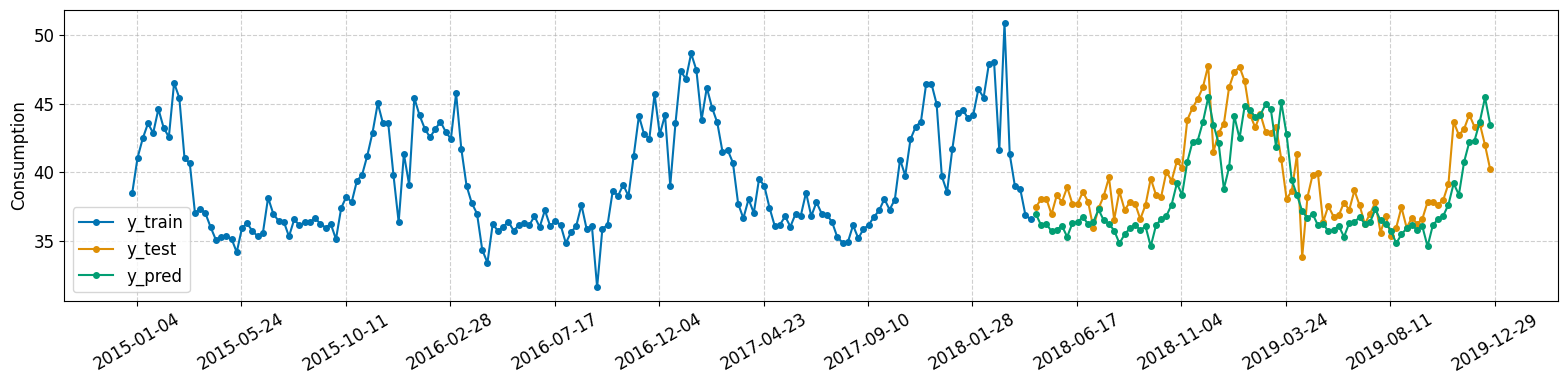

In [33]:
forecaster = StatsForecastMSTL(season_length=SEASON,)  
forecaster.fit(y_train_)
y_pred = forecaster.predict(fh)

y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train_, y_test_, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

print_metrics(y_test_, y_pred, y_pred_naive)

## Доп методы

### TBATS

Другим методом расширяющим семейство экпонециальных моделей является модели `BATS` и `TBATS`. Это методы, включающи в едином фреймровке несколько последовательных операций. Более того модели расширяют семейство экспоненциальных моделей, позволяя выделять в них несколько сезонных составляющих отдельно. Такие операции как:
* Преобразование [<tt>Box-Cox</tt>](https://otexts.com/fpp3/transformations.html)
* [Аппроксимация тренда](https://otexts.com/fpp3/regression.html),
* Выделение сезонных частей,
* описание остатков разложения в виде т.н. [<tt>ARMA</tt>](https://otexts.com/fpp3/arima.html) модели (она будет изучаться в следующих юнитах).
Описанная последовательность составляет модель [`BATS`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.bats.BATS.html). В модели [`TBATS`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.tbats.TBATS.html) к последовательности добавляется операция разложения сезонноых составляющих в ряд фурье и оценка коэффициентов для компонент ряда. Такая операция позволяет описать не стационарную сезонность.
В оригинале модели `BATS` и `TBATS` описаны [в отдельном фреймворке](https://github.com/intive-DataScience/tbats), который включен в [sktime](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.tbats.TBATS.html).

>**BATS model** означает (Exponential smoothing state space model with Box-Cox transformation, ARMA errors, Trend and Seasonal components) \
> **TBATS model** означает (Exponential smoothing state space model with Box-Cox transformation, ARMA errors, Trend and Seasonal components)

In [34]:
forecaster = TBATS(
    use_box_cox=True,
    use_trend=True,
    use_damped_trend=True,
    sp=[SEASON],
    use_arma_errors=True,
    n_jobs=-1)

forecaster.fit(y_train)

fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)

# Визуализация
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

print_metrics(y_test, y_pred, y_pred_naive)

ModuleNotFoundError: TBATS requires package 'tbats' to be present in the python environment, but 'tbats' was not found. 'tbats' is a dependency of TBATS and required to construct it. To install the requirement 'tbats', please run: `pip install tbats` 

### Prophet

В конце также рассмотрим пример метода обобщенной регрессии: `Prophet`. Напомним, что это метод предсказания временных рядов на основе т.н. обобщенной регрессии для модели бизнес процессов, которая включает тренд с точками перегиба и насыщением, несколько компонент сезонности и редкие, но регулярные события (типа выходных дней). 
> Отметим что модель является не единственной в своем классе, однако одной из наиболее популярных. В том числе модель может быть расширена для преодоления своих недостатков при помощи модели [`neural prophet`](https://github.com/ourownstory/neural_prophet). А также могут быть пострены свои [<tt>prophet</tt>-подобные](https://www.pymc.io/projects/examples/en/latest/time_series/Air_passengers-Prophet_with_Bayesian_workflow.html) модели.

<!-- https://habr.com/ru/companies/otus/articles/555700/ -->

In [ ]:
forecaster = Prophet(seasonality_mode='additive',
                     n_changepoints=int(len(y_train) / 4),
                     add_country_holidays={'country_name': 'Germany'},
                     yearly_seasonality=True)

forecaster.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)

print_metrics(y_test, y_pred, y_pred_naive)

## Многосезонный ВР

### Задание ряда

Зададим дневную сезонность

In [ ]:
y = df.Consumption.asfreq('D')
#y.index = y.index.to_period("W")
SEASON = [7,365] # 53 недели в году
y.head()

In [ ]:
TEST_SIZE = int(0.544*y.size)

y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

print(f'Check splitted data size: Train: {y_train.shape[0]}, Test: {y_test.shape[0]}')

plot_series(y_train, y_test, labels=["y_train", "y_test"]); fix_plot(y,tick_step=100,)

In [ ]:
forecaster = NaiveForecaster(strategy="last")
forecaster.fit(y_train)

fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]); fix_plot(y, tick_step=100);
y_pred_naive = y_pred
# ОШИБКА
print_metrics(y_test, y_pred, y_pred)

### Разложение на компоненты

In [ ]:
deseason = Deseasonalizer(model="additive", sp=SEASON[1]) #Remove seasonal components from a time series.
season7   = y_train.values.squeeze() - deseason.fit_transform(y_train.values).squeeze()
deseason = Deseasonalizer(model="additive", sp=SEASON[0]) #Remove seasonal components from a time series.
season53   = y_train.values.squeeze() - deseason.fit_transform(y_train.values).squeeze()
season = season7+season53
detrend  = Detrender(forecaster=TrendForecaster())
trend    = y_train.values.squeeze() - detrend.fit_transform(y_train.values).squeeze()
residual = y_train.values.squeeze() - trend - season

plt.plot(season, c='k', label='season')
plt.plot(trend, c='g', label='trend')
plt.plot(residual, c='r', label='residual')
plt.plot(y_train.values, c='b', label='original data')
plt.legend()
plt.show()

остаток довольно значимый и видимо свзязан с неточностью периода, а также с празднечными днями.

In [ ]:
# Оставляем дневные данные
y_train_ = y_train.copy().asfreq('D') # <-- дневная частота
y_test_  = y_test.copy().asfreq('D')    # <-- дневная частота

# Горизонт предсказания
fh = ForecastingHorizon(y_test_.index, is_relative=False)


# Пайплайн SES через deseasonalize + polynomial detrend
forecaster = TransformedTargetForecaster(
    steps=[
        ("deseasonalize7", Deseasonalizer(model="multiplicative", sp=SEASON[0])), 
        ("deseasonalize53", Deseasonalizer(model="multiplicative", sp=SEASON[1])), 
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
        ("forecaster", ExponentialSmoothing(trend=None, seasonal=None))  # SES
    ])

# Обучение
forecaster.fit(y_train_)

# Предсказание
y_pred = forecaster.predict(fh)

# Приведение индекса
y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train_, y_test_, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y, tick_step=100)

print_metrics(y_test_, y_pred, y_pred_naive)

In [ ]:
# Оставляем дневные данные
y_train_ = y_train.copy().asfreq('D')  
y_test_  = y_test.copy().asfreq('D')     

# Горизонт предсказания
fh = ForecastingHorizon(y_test_.index, is_relative=False)


# Пайплайн SES через deseasonalize + polynomial detrend
forecaster = TransformedTargetForecaster(
    steps=[
        ("deseasonalize7", Deseasonalizer(model="multiplicative", sp=SEASON[0])), 
        ("deseasonalize53", Deseasonalizer(model="multiplicative", sp=SEASON[1])), 
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
    ("forecaster", ExponentialSmoothing(trend="add", seasonal="add",sp=7))  # SES
    ])

# Обучение
forecaster.fit(y_train_)

# Предсказание
y_pred = forecaster.predict(fh)

# Приведение индекса
y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train_, y_test_, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y, tick_step=100)

print_metrics(y_test_, y_pred, y_pred_naive)

In [ ]:
forecaster = StatsForecastMSTL(season_length=SEASON,)  
forecaster.fit(y_train)
y_pred = forecaster.predict(fh)

y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y,tick_step=100)

print_metrics(y_test_, y_pred, y_pred_naive)

In [ ]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, mean_squared_error

def print_metrics(y_true, y_pred_complex, y_pred_naive):
    smape = MeanAbsolutePercentageError(symmetric=True)

    s_c = smape(y_pred_complex, y_true)
    s_n = smape(y_pred_naive, y_true)
    skill = 1 - s_c / s_n

    # используем square_root=True для RMSE
    rmse_complex = mean_squared_error(y_true, y_pred_complex, square_root=True)

    print(f"sMAPE: {s_c:.3f}")
    print(f"RMSE:  {rmse_complex:.3f}")
    print(f"Skill: {skill:.3f}")

In [ ]:

forecaster = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=0.5,  # уменьшили — сезонность будет мягче
    changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
    add_country_holidays={'country_name': 'Germany'},
    weekly_seasonality=True,
    yearly_seasonality=True
)

forecaster.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y,tick_step=100)

print_metrics(y_test, y_pred, y_pred_naive)

### Часовая сезонность

In [ ]:
y = df.Consumption.asfreq('H')
#y.index = y.index.to_period("W")
SEASON = [24,24*7,int(24*365.25)] 

y.head()

In [ ]:
TEST_SIZE = int(0.544*y.size)

y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

print(f'Check splitted data size: Train: {y_train.shape[0]}, Test: {y_test.shape[0]}')

plot_series(y_train, y_test, labels=["y_train", "y_test"]); fix_plot(y,tick_step=24*100,)

In [ ]:
forecaster = NaiveForecaster(strategy="last")
forecaster.fit(y_train)

fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)

# plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]); fix_plot(y, tick_step=24*100);
y_pred_naive = y_pred
# ОШИБКА
print_metrics(y_test, y_pred, y_pred)

In [ ]:

y_train_ = y_train.copy().asfreq('H') # <-- дневная частота
y_test_  = y_test.copy().asfreq('H')    # <-- дневная частота

# Горизонт предсказания
fh = ForecastingHorizon(y_test_.index, is_relative=False)


# Пайплайн SES через deseasonalize + polynomial detrend
forecaster = TransformedTargetForecaster(
    steps=[
        ("deseasonalize1", Deseasonalizer(model="multiplicative", sp=SEASON[0])), 
        ("deseasonalize7", Deseasonalizer(model="multiplicative", sp=SEASON[1])),
        ("deseasonalize53", Deseasonalizer(model="multiplicative", sp=SEASON[2])),
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
        ("forecaster", ExponentialSmoothing(trend=None, seasonal=None))  # SES
    ])

# Обучение
forecaster.fit(y_train_)

# Предсказание
y_pred = forecaster.predict(fh)

# Приведение индекса
y_pred = y_pred.reindex(y_test_.index)

# Визуализация
plot_series(y_train_, y_test_, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y, tick_step=24*100)

print_metrics(y_test_, y_pred, y_pred_naive)

In [ ]:
from sklearn.metrics import mean_squared_error as mse_sk
from sklearn.metrics import mean_absolute_percentage_error

def print_metrics(y_true, y_pred_complex, y_pred_naive):
    # sklearn MAPE не поддерживает symmetric, поэтому используем sktime
    from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
    smape = MeanAbsolutePercentageError(symmetric=True)

    s_c = smape(y_pred_complex, y_true)
    s_n = smape(y_pred_naive, y_true)
    skill = 1 - s_c / s_n

    rmse_complex = mse_sk(y_true, y_pred_complex) ** 0.5

    print(f"sMAPE: {s_c:.3f}")
    print(f"RMSE:  {rmse_complex:.3f}")
    print(f"Skill: {skill:.3f}")

In [ ]:
forecaster = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
    changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
    add_country_holidays={'country_name': 'Germany'},
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=True,
)

forecaster.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y,tick_step=24*100)

print_metrics(y_test, y_pred, y_pred_naive)